# Notebook 6b — Full Tabular Cleaning, Harmonisation & Imputation

## Purpose

This notebook performs the final cleaning, harmonisation, and imputation pass on the fully merged tabular dataset, producing the analysis-ready file used for descriptive statistics and clustering.

---

## Pipeline Overview

### I. Raw data audit (pre-imputation)
The full merged dataset (`df_adm_pv_ioa_med_radio_labo_uhcd_tabular.csv`) is loaded. All date columns are standardised to ISO 8601 format. Whitespace-only strings are converted to NaN. A missing-data report and visualisation (bar chart sorted by missingness rate) are produced to guide imputation decisions.

### II. Imputation
Two imputation strategies are applied:

- **Clinical norm imputation** for continuous and categorical vital signs: `CLINICAL_NORMS` maps each vital (temperature, heart rate, blood pressure, SpO2, respiratory rate, GCS, blood glucose, pain score, etc.) and `transport_grouped` to a clinically sensible default value. Only true NaNs are filled; measurement flags (`is_*_measured`, `*_status`) are left unchanged.
- **Median imputation** for the 49 records with missing triage duration, pending future cluster-median refinement.

Outcome text fields (`diag`, `disposition_med`, `disposition`) are standardised to lowercase and missing values are set to `'unknown'`.

### III. Descriptive summary (post-imputation)
A structured `get_descriptive_table()` function produces separate numeric (mean, SD, min, max, missingness) and categorical (N, %) summaries, excluding raw lab values, imaging exam labels, and administrative identifiers.

### IV. Exclusions and final cleaning
- Rows without a triage score are removed.
- Paediatric patients and a small residual category (`bronchiolite du nourrisson`) are excluded.
- Chief complaints are translated from French to English via a `COMPLAINT_TRANSLATION` dictionary and grouped into 17 clinical categories (`complaint_category`: Trauma, Cardiovascular, Neurological, Respiratory, etc.) via `COMPLAINT_GROUPS_EN`.

### V. Export
The cleaned, imputed, and annotated dataset is saved as `df_final_binaire_imputed.csv`, the input file for all downstream analyses (descriptive statistics in Notebook 7, clustering in Notebooks 8+).

# I. ANALYSE DES DONNEES BRUTES AVANT IMPUTATION

In [340]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading file
df_tabular = pd.read_csv("Datasets/df_adm_pv_ioa_med_radio_labo_uhcd_tabular.csv", sep=',')



/tmp/ipykernel_3141514/2646247581.py:8: DtypeWarning: Columns (12,77,78,81,83,84,85,87,88,89,90,91,92,96,98,100,101,103,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,121,122,125,129,131,132,133,134,135,136,137,140,141,142,143,144,145,181) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tabular = pd.read_csv("Datasets/df_adm_pv_ioa_med_radio_labo_uhcd_tabular.csv", sep=',')


# Set all date in date hour format

In [341]:
import pandas as pd
import numpy as np

# 1. Identify all columns with "date" in the name
date_columns = [col for col in df_tabular.columns if 'date' in col.lower()]

for col in date_columns:
    try:
        # 2. Convert to datetime objects
        df_tabular[col] = pd.to_datetime(df_tabular[col], errors='coerce')

        # 3. Apply the ISO 8601 Default Format: YYYY-MM-DD HH:MM:SS
        # This is the cleanest format for data processing and sorting
        df_tabular[col] = df_tabular[col].dt.strftime('%Y-%m-%d %H:%M:%S')

        # 4. Handle missing values
        df_tabular[col] = df_tabular[col].replace('NaT', np.nan)

    except Exception as e:
        print(f"⚠️ Could not process column '{col}': {e}")

print("✅ All date columns are now in ISO 8601 Default Format (YYYY-MM-DD HH:MM:SS).")
display(df_tabular[date_columns].head())

✅ All date columns are now in ISO 8601 Default Format (YYYY-MM-DD HH:MM:SS).


,datetime_admission,date_sortie_urg,date_sortie_chu,date_sortie_urg_completee,date_hour_triage_begin,date_hour_triage_end,sample_date
0,2022-01-01 00:08:00,2022-01-02 09:33:00,2022-01-02 19:00:00,2022-01-01 00:09:00,2022-01-01 00:19:00,2022-01-01 00:29:00,2022-01-01 01:00:00
1,2022-01-01 00:17:00,2022-01-02 14:55:00,2022-01-10 15:12:00,NaN,2022-01-01 00:28:00,2022-01-01 00:33:00,2022-01-01 01:05:00
2,2022-01-01 00:22:00,2022-01-01 13:15:00,2022-01-01 13:15:00,2022-01-01 02:00:00,2022-01-01 00:34:00,2022-01-01 00:40:00,2022-01-01 01:20:00
3,2022-01-01 00:31:00,2022-01-01 02:05:00,2022-01-01 02:05:00,2022-01-01 02:05:00,2022-01-01 00:49:00,2022-01-01 00:52:00,NaN
4,2022-01-01 00:35:00,2022-01-01 06:24:00,2022-01-01 06:24:00,2022-01-01 06:24:00,2022-01-01 00:42:00,2022-01-01 00:47:00,2022-01-01 03:00:00


# Missing data check

In [342]:
print(df_tabular.columns.tolist())

['nda', 'sex', 'age', 'uam_service', 'hospital', 'datetime_admission', 'date_sortie_urg', 'date_sortie_chu', 'date_sortie_urg_completee', 'mode_sortie_chu', 'decision_urgence', 'transport_grouped', 'date_hour_triage_begin', 'date_hour_triage_end', 'duration_triage_ioa_min', 'chief_complaint', 'triage', 'triage_raw', 'sbp', 'dbp', 'mbp', 'bp_status', 'is_bp_measured', 'hr', 'hr_status', 'is_hr_measured', 'temp', 'temp_status', 'is_temp_measured', 'sat', 'sat_status', 'is_sat_measured', 'rr', 'rr_status', 'is_rr_measured', 'o2_flow', 'o2_flow_status', 'is_o2_measured', 'gcs', 'gcs_status', 'is_gcs_measured', 'cap_blood_sugar_mmol_L', 'cap_blood_sugar_status', 'is_cap_blood_sugar_mmol_L_measured', 'pupil_right', 'pupil_left', 'pupils_status', 'anisocoria_status', 'is_pupils_measured', 'urine_dipstick_clean', 'is_urine_dipstick_clean_measured', 'urine_dipstick_clean_status', 'pain', 'pain_status', 'is_pain_measured', 'breathalyzer', 'breathalyzer_status', 'is_breathalyzer_measured', 'hemoc

✅ Cleaning complete: Whitespace-only strings converted to NaN.

📊 MISSING DATA STATISTICS (df_tabular):
------------------------------------------------------------
                           Missing Values  Percentage (%)
axa_orgaran                         57389      100.000000
xray_4                              57388       99.998258
mri_3                               57388       99.998258
radio_interventional_2              57388       99.998258
nuclear_medicine_2                  57387       99.996515
axa_arixtra                         57387       99.996515
lcr_aspect_1                        57384       99.991288
ct_scan_3                           57383       99.989545
nuclear_medicine_1                  57381       99.986060
xray_3                              57372       99.970378
ultrasound_2                        57371       99.968635
aiia_pradaxa                        57319       99.878025
mri_2                               57314       99.869313
axa_hbpm               

/tmp/ipykernel_3141514/498611433.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Variable', data=plot_data, palette="viridis")
/tmp/ipykernel_3141514/498611433.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


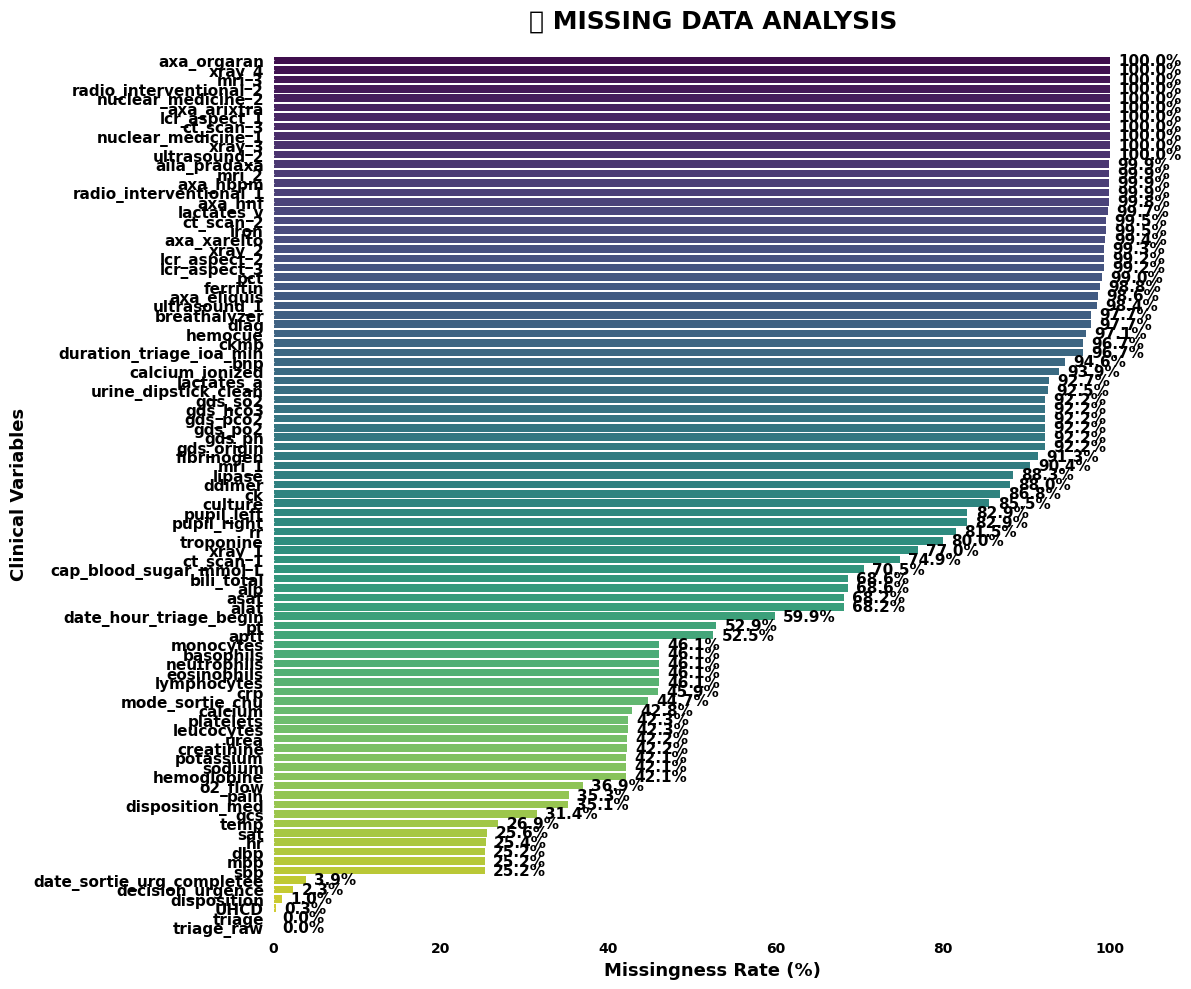

In [343]:
# ====================================================
# STEP 1: MISSING DATA ANALYSIS
# ====================================================


# Ensure all columns with NaNs are visible in the console
pd.set_option('display.max_rows', None)

# Handle empty strings and whitespace-only cells in 'diag'
# This addresses your discovery that 'diag' had ~20% hidden missing values
df_tabular = df_tabular.replace(r'^\s*$', np.nan, regex=True)
print("✅ Cleaning complete: Whitespace-only strings converted to NaN.")

# Calculate missing value statistics
missing_count = df_tabular.isnull().sum()
missing_percentage = (missing_count / len(df_tabular)) * 100

# Create summary DataFrame
df_missing = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

# Filter for variables with at least one missing entry
df_missing_filtered = df_missing[df_missing['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("\n📊 MISSING DATA STATISTICS (df_tabular):")
print("-" * 60)
print(df_missing_filtered)
print("-" * 60)
print(f"Total columns with missing data: {len(df_missing_filtered)} out of {df_tabular.shape[1]}")

# =========================================================
# STEP 2: VISUALIZATION OF MISSING DATA
# ==========================================================

# 1. Filter criteria: exclude technical status columns and specific timestamps
to_exclude = ['sample_date', 'date_hour_vitals']
df_plot_final = df_missing_filtered[
    (~df_missing_filtered.index.str.endswith('_status')) &
    (~df_missing_filtered.index.isin(to_exclude))
]

# 2. Data Preparation for Plotting
plot_data = df_plot_final.reset_index()
plot_data.columns = ['Variable', 'Count', 'Percentage']

# 3. Figure Creation
plt.figure(figsize=(12, 10), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# 4. Barplot Generation
sns.barplot(x='Percentage', y='Variable', data=plot_data, palette="viridis")

# 5. Styling (Black text for high contrast and readability)
plt.title('📊 MISSING DATA ANALYSIS', fontsize=18, fontweight='bold', color='black', pad=20)
plt.xlabel('Missingness Rate (%)', fontsize=13, fontweight='bold', color='black')
plt.ylabel('Clinical Variables', fontsize=13, fontweight='bold', color='black')

plt.yticks(color='black', fontweight='bold', fontsize=11)
plt.xticks(color='black', fontweight='bold')

# 6. Annotate bars with percentage values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%',
                (width + 1, p.get_y() + p.get_height()/2),
                va='center', fontsize=11, fontweight='bold', color='black')

# Clean up layout by removing redundant spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Pour le diagnostic, à date je peux rien faire, pour le transport je fvais rajouter un lvl "inconnu", et pour le reste des signes vitaux je vais imputer les vraies données manquantes par la norme et creer une variable is_measured binaire pour différencier les vrais NaN (non mesurés) des valeurs imputées (mesurés mais normalisés). Parcontre pour les données abbérantes je les mettrai en Nan dans un second temps, et essayé d'imputer par la mediane du cluster (après avoir fait du clustering sur les données brutes) pour garder une cohérence clinique. je creerai une colonne indicative aussi pour differencier celles qui étaient aberrantes, mais pour moi cette colonne n'a rien a faire dans le clustering final, elle servira juste pour la transparence et la vérification de la qualité de l'imputation.

# II. IMPUTATION PAR LA NORME POUR LES SIGNES VITAUX MANQUANTS (+> finalement non on laisse NAN et jsute flag) ET PAR INCONNU POUR LE TRANSPORT #

In [344]:
#==============================================================================
# IMPUTATION BY CLINICAL NORM — NaN only, flags and status unchanged
# ==============================================================================

CLINICAL_NORMS = {
    # Numeric vitals
    "temp":                   37.0,
    "hr":                     75.0,
    "sbp":                    120.0,
    "dbp":                    70.0,
    "sat":                    98.0,
    "rr":                     18.0,
    "gcs":                    15.0,
    "cap_blood_sugar_mmol_L": 5.5,
    "pain":                   0.0,
    "pupil_right":            3.0,
    "pupil_left":             3.0,
    "o2_flow":                0.0,
    "hemocue":                13.0,
    "breathalyzer":           0.0,

    # Categorical
    "urine_dipstick_clean":   "negative",
    "transport_grouped":      "unknown",
}

def impute_by_norm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace NaN values with clinical norms.
    Flags (is_*_measured) and status (*_status) are NOT touched.
    """
    df = df.copy()

    for col, norm in CLINICAL_NORMS.items():
        if col in df.columns:
            n_missing = df[col].isna().sum()
            if n_missing > 0:
                df[col] = df[col].fillna(norm)
                print(f"  {col} : {n_missing} NaN → {norm}")

    print("\n✅ Imputation by norm complete — flags and status unchanged.")
    return df


# ── Call ───────────────────────────────────────────────────────────────────────
df_imputed = impute_by_norm(df_tabular)

  temp : 15421 NaN → 37.0
  hr : 14552 NaN → 75.0
  sbp : 14473 NaN → 120.0
  dbp : 14475 NaN → 70.0
  sat : 14667 NaN → 98.0
  rr : 46795 NaN → 18.0
  gcs : 18039 NaN → 15.0
  cap_blood_sugar_mmol_L : 40486 NaN → 5.5
  pain : 20260 NaN → 0.0
  pupil_right : 47565 NaN → 3.0
  pupil_left : 47582 NaN → 3.0
  o2_flow : 21190 NaN → 0.0
  hemocue : 55724 NaN → 13.0
  breathalyzer : 56067 NaN → 0.0
  urine_dipstick_clean : 53080 NaN → negative

✅ Imputation by norm complete — flags and status unchanged.


In [345]:
def inspect_status_orphans(df):
    # Dictionnaire des paires (Valeur numérique : Colonne Statut)
    check_pairs = {
        'temp': 'temp_status',
        'hr': 'hr_status',
        'sat': 'sat_status',
        'rr': 'rr_status',
        'gcs': 'gcs_status',
        'cap_blood_sugar_mmol_L': 'cap_blood_sugar_status',
        'pain': 'pain_status',
        'hemocue': 'hemocue_status'
    }

    print(f"\n{'!'*20} ORPHAN VALUES REPORT {'!'*20}")
    found_any = False

    for val_col, stat_col in check_pairs.items():
        if val_col in df.columns and stat_col in df.columns:
            # On cherche : Valeur présente MAIS Statut est NaN
            orphans = df[df[stat_col].isna() & df[val_col].notna()]

            if not orphans.empty:
                found_any = True
                print(f"\n⚠️ Column [{val_col}] has {len(orphans)} values not captured by [{stat_col}]:")
                # On affiche les valeurs uniques qui posent problème pour comprendre pourquoi
                problem_values = sorted(orphans[val_col].unique())
                print(f"   --> Problematic values: {problem_values}")

                # Optionnel : voir les premières lignes concernées
                # display(orphans[[val_col, stat_col]].head(5))

    if not found_any:
        print("\n✅ Perfect! All numeric values have a corresponding clinical status.")

# Appel de l'inspection
inspect_status_orphans(df_imputed)


!!!!!!!!!!!!!!!!!!!! ORPHAN VALUES REPORT !!!!!!!!!!!!!!!!!!!!

✅ Perfect! All numeric values have a corresponding clinical status.


In [346]:
# =========================================================
# FINAL OUTCOME CLEANING & MISSING DURATION AUDIT
# =========================================================

# --- 1. CLEANING DIAGNOSIS & DISPOSITION ---
# These represent our clinical labels for the triage project.
outcome_cols = ['diag', 'disposition_med', 'disposition']



print("🧹 Cleaning outcomes and imputing 'unknown' for missing labels...")

for col in outcome_cols:
    if col in df_imputed.columns:
        # Standardize text (lowercase & strip whitespace)
        df_imputed[col] = df_imputed[col].astype(str).str.lower().str.strip()

        # Replace text-based nulls with 'unknown'
        df_imputed[col] = df_imputed[col].replace(['nan', 'none', '', 'nat', 'null'], 'unknown')

        # Final safety fill for true NaNs
        df_imputed[col] = df_imputed[col].fillna('unknown')

print(f"✅ NaNs remaining in 'diag'        : {df_imputed['diag'].isna().sum()}")
print(f"✅ NaNs remaining in 'disposition_med' : {df_imputed['disposition_med'].isna().sum()}")
print(f"✅ NaNs remaining in 'disposition' : {df_imputed['disposition'].isna().sum()}")

# --- 2. INVESTIGATING MISSING TRIAGE DURATIONS ---
# Duration is a key feature for clustering (GMM). We need to know why 49 records are missing it.
mask_missing_duration = df_imputed['duration_triage_ioa_min'].isna()
df_check_time = df_imputed.loc[mask_missing_duration,
                               ['date_hour_triage_begin', 'date_hour_triage_end', 'duration_triage_ioa_min']].copy()

print(f"\n🔍 INVESTIGATING {len(df_check_time)} RECORDS WITH MISSING DURATION:")
print("-" * 60)

if not df_check_time.empty:
    # Display the first 10 problematic timestamps
    display(df_check_time.head(10))

    # Quick Diagnostic: Are the timestamps themselves missing?
    missing_begin = df_check_time['date_hour_triage_begin'].isna().sum()
    missing_end = df_check_time['date_hour_triage_end'].isna().sum()

    print(f"\n📊 Diagnostic Summary:")
    print(f"- Missing 'begin' timestamp : {missing_begin}")
    print(f"- Missing 'end' timestamp   : {missing_end}")
    print(f"💡 Note: If timestamps exist but duration is NaN, check for negative intervals or format errors.")
else:
    print("✅ No missing durations found.")

# --- 3. FINAL IMPUTATION FOR DURATION (Cluster Median) ---
# As per your pipeline [2026-01-23]: Impute aberrant data with Cluster Median
# For now, we use global median until clusters are defined.
if df_imputed['duration_triage_ioa_min'].isna().any():
    median_val = df_imputed['duration_triage_ioa_min'].median()
    df_imputed['duration_triage_ioa_min'] = df_imputed['duration_triage_ioa_min'].fillna(median_val)
    print(f"\n📥 Final Imputation: {len(df_check_time)} durations filled with median ({median_val} min).")

🧹 Cleaning outcomes and imputing 'unknown' for missing labels...
✅ NaNs remaining in 'diag'        : 0
✅ NaNs remaining in 'disposition_med' : 0
✅ NaNs remaining in 'disposition' : 0

🔍 INVESTIGATING 55483 RECORDS WITH MISSING DURATION:
------------------------------------------------------------


,date_hour_triage_begin,date_hour_triage_end,duration_triage_ioa_min
29,2022-01-01 08:08:00,2022-01-01 08:09:00,NaN
51,2022-01-01 13:40:00,2022-01-01 13:41:00,NaN
59,2022-01-01 16:28:00,2022-01-01 16:29:00,NaN
82,2022-02-01 03:43:00,2022-01-02 03:51:00,NaN
91,2022-02-01 01:13:00,2022-01-02 01:16:00,NaN
92,2022-02-01 00:10:00,2022-01-02 00:11:00,NaN
93,2022-02-01 01:08:00,2022-01-02 01:09:00,NaN
94,2022-02-01 01:30:00,2022-01-02 01:35:00,NaN
95,2022-02-01 01:45:00,2022-01-02 01:50:00,NaN
96,2022-02-01 01:53:00,2022-01-02 01:58:00,NaN



📊 Diagnostic Summary:
- Missing 'begin' timestamp : 34361
- Missing 'end' timestamp   : 0
💡 Note: If timestamps exist but duration is NaN, check for negative intervals or format errors.

📥 Final Imputation: 55483 durations filled with median (5.0 min).


# III. DATA DESCRIPTION AND VISUALIZATION #

In [347]:
# =========================================================
# STEP 3: POST-IMPUTATION DESCRIPTIVE TABLE (CORRECTED)
# =========================================================

# format date
date_columns = [col for col in df_tabular.columns if 'date' in col.lower()]

for col in date_columns:
    df_tabular[col] = pd.to_datetime(df_tabular[col], errors='coerce')

print(f"✅ {len(date_columns)} date columns converted to datetime:")
print(date_columns)


def get_descriptive_table(df, title):
    """
    Generates a comprehensive summary of clinical data post-imputation.
    Excludes identifiers, dates, and lab results.
    """
    print(f"\n{'=' * 30} {title.upper()} {'=' * 30}")

    # 1. Define lists to exclude
    lab_results = [
        'alat', 'asat', 'axa_hnf', 'axa_arixtra', 'axa_eliquis', 'axa_hbpm',
        'axa_xarelto', 'aiia_pradaxa', 'bnp', 'gds_hco3', 'bili_total', 'ck',
        'ckmb', 'crp', 'calcium_ionized', 'calcium', 'creatinine', 'ddimer',
        'iron', 'ferritin', 'fibrinogen', 'hemoglobine', 'lactates_a',
        'lactates_v', 'leucocytes', 'lipase', 'lymphocytes', 'monocytes',
        'alp', 'basophils', 'eosinophils', 'neutrophils', 'platelets',
        'potassium', 'pct', 'gds_so2', 'sodium', 'aptt', 'pt', 'troponine',
        'urea', 'culture', 'gds_origin', 'lcr_aspect_1', 'lcr_aspect_2',
        'lcr_aspect_3', 'gds_pco2', 'gds_ph', 'gds_po2'
    ]

    cols_imaging = [
        'ultrasound_1', 'ultrasound_2', 'ct_scan_1', 'ct_scan_2', 'ct_scan_3',
        'xray_1', 'xray_2', 'xray_3', 'mri_1', 'mri_2',
        'radio_interventional_1', 'nuclear_medicine_1'
    ]

    base_exclude = [
        'nda', 'sample_date', 'chief_complaint', 'datetime_admission', 'date_sortie_urg', 'date_sortie_chu',
        'date_sortie_urg_completee',
        'date_hour_triage_begin', 'date_hour_triage_end', 'diag',
    ]

    # CORRECT WAY: Merge the lists into one flat list
    total_exclude = base_exclude + lab_results + cols_imaging

    # 2. Smart column classification
    numeric_cols = []
    categorical_cols = []

    for col in df.columns:
        if col in total_exclude:
            continue

        # Logic: If it has these prefixes/suffixes, it's CATEGORICAL (even if numeric 0/1)
        is_status_var = any(col.startswith(pre) for pre in ['has_', 'is_', 'had_']) or col.endswith('_status')

        if is_status_var:
            categorical_cols.append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)

    # 3. NUMERIC SUMMARY (Vitals, Age, etc.)
    if numeric_cols:
        print("\n📊 --- NUMERIC VARIABLES (Vitals & Demographics) ---")
        num_summary = df[numeric_cols].agg(['count', 'mean', 'std', 'min', 'max']).T
        num_summary['missing_%'] = (df[numeric_cols].isna().sum() / len(df) * 100).round(2)
        display(num_summary.round(2))

    # 4. CATEGORICAL & STATUS SUMMARY
    if categorical_cols:
        print("\n📋 --- CATEGORICAL & STATUS DISTRIBUTIONS ---")
        summaries = []
        for col in categorical_cols:
            counts = df[col].value_counts(dropna=False)
            percents = (df[col].value_counts(dropna=False, normalize=True) * 100).round(1)

            temp_df = pd.DataFrame({
                'Variable': col,
                'Level': counts.index,
                'N': counts.values,
                'Percentage (%)': percents.values
            })
            summaries.append(temp_df)

        final_cat_summary = pd.concat(summaries, ignore_index=True)
        display(final_cat_summary)


# --- FINAL EXECUTION ---
get_descriptive_table(df_imputed, "Post-Imputation Clinical Profile")


####### virer les radio detailedet date sortie la setter en date


✅ 7 date columns converted to datetime:
['datetime_admission', 'date_sortie_urg', 'date_sortie_chu', 'date_sortie_urg_completee', 'date_hour_triage_begin', 'date_hour_triage_end', 'sample_date']

============================== POST-IMPUTATION CLINICAL PROFILE ==============================

📊 --- NUMERIC VARIABLES (Vitals & Demographics) ---


,count,mean,std,min,max,missing_%
age,57389.0,47.48,23.00,0.00,108.0,0.00
uam_service,57389.0,9780.00,0.00,9780.00,9780.0,0.00
duration_triage_ioa_min,57389.0,5.05,0.73,2.00,29.0,0.00
triage,57384.0,3.13,0.91,1.00,5.0,0.01
sbp,57389.0,127.78,20.16,47.00,266.0,0.00
dbp,57389.0,74.99,13.01,20.00,164.0,0.00
mbp,42914.0,94.58,15.68,31.00,195.3,25.22
hr,57389.0,79.06,14.55,20.00,220.0,0.00
temp,57389.0,36.86,0.49,31.20,40.6,0.00
sat,57389.0,97.80,1.83,45.00,100.0,0.00



📋 --- CATEGORICAL & STATUS DISTRIBUTIONS ---


,Variable,Level,N,Percentage (%)
0,sex,M,30202,52.6
1,sex,F,27186,47.4
2,sex,I,1,0.0
3,hospital,PEL,57389,100.0
4,mode_sortie_chu,A - Domicile,27804,48.4
5,mode_sortie_chu,NaN,25670,44.7
6,mode_sortie_chu,B4 - Transfert PSY,974,1.7
7,mode_sortie_chu,B2 - Transfert SSR,959,1.7
8,mode_sortie_chu,B1 - Transfert MCO,892,1.6
9,mode_sortie_chu,C0 - Décédé,848,1.5


In [348]:
# =========================================================
# STEP 3: POST-IMPUTATION DESCRIPTIVE TABLE
# =========================================================

# --- FINAL EXECUTION ---
get_descriptive_table(df_imputed, "Post-Imputation Clinical Profile")


============================== POST-IMPUTATION CLINICAL PROFILE ==============================

📊 --- NUMERIC VARIABLES (Vitals & Demographics) ---


,count,mean,std,min,max,missing_%
age,57389.0,47.48,23.00,0.00,108.0,0.00
uam_service,57389.0,9780.00,0.00,9780.00,9780.0,0.00
duration_triage_ioa_min,57389.0,5.05,0.73,2.00,29.0,0.00
triage,57384.0,3.13,0.91,1.00,5.0,0.01
sbp,57389.0,127.78,20.16,47.00,266.0,0.00
dbp,57389.0,74.99,13.01,20.00,164.0,0.00
mbp,42914.0,94.58,15.68,31.00,195.3,25.22
hr,57389.0,79.06,14.55,20.00,220.0,0.00
temp,57389.0,36.86,0.49,31.20,40.6,0.00
sat,57389.0,97.80,1.83,45.00,100.0,0.00



📋 --- CATEGORICAL & STATUS DISTRIBUTIONS ---


,Variable,Level,N,Percentage (%)
0,sex,M,30202,52.6
1,sex,F,27186,47.4
2,sex,I,1,0.0
3,hospital,PEL,57389,100.0
4,mode_sortie_chu,A - Domicile,27804,48.4
5,mode_sortie_chu,NaN,25670,44.7
6,mode_sortie_chu,B4 - Transfert PSY,974,1.7
7,mode_sortie_chu,B2 - Transfert SSR,959,1.7
8,mode_sortie_chu,B1 - Transfert MCO,892,1.6
9,mode_sortie_chu,C0 - Décédé,848,1.5


# IV. Removing NAs, removing pediatric, and cleaning

## Removing lines without triage score ##

In [349]:
n_before = len(df_imputed)
df_imputed = df_imputed[df_imputed['triage'].notna()].copy()
print(f"Rows removed  : {n_before - len(df_imputed):,}")
print(f"Rows remaining: {len(df_imputed):,}")

Rows removed  : 5
Rows remaining: 57,384


## Removing lines without unknown disposition

In [350]:
n_before = len(df_imputed)
df_imputed = df_imputed[df_imputed['disposition'] != 'unknown'].copy()
print(f"Rows removed  : {n_before - len(df_imputed):,}")
print(f"Rows remaining: {len(df_imputed):,}")

Rows removed  : 548
Rows remaining: 56,836


## Removing pediatric cases and physiological cleaning ##

In [351]:
# ====================================================================================
# STEP ?: FINAL PHYSIOLOGICAL CLEANING & PEDIATRIC FILTERING
# ====================================================================================

# 1. PEDIATRIC FILTER (Adults >= 15 years old only)
if 'age' in df_imputed.columns:
    initial_total = len(df_imputed)
    df_imputed = df_imputed[df_imputed['age'] >= 15].reset_index(drop=True)
    print(f"🚫 PEDIATRIC FILTER: Removed {initial_total - len(df_imputed)} patients under 15.")

# 2. PHYSIOLOGICAL OUTLIER REMOVAL
# Thresholds adjusted for clinical reality (High Glucose capped at 33.3 mmol/L)
bounds = {
    'sbp': (50, 300), 'dbp': (30, 200), 'hr': (20, 300),
    'temp': (25, 43), 'sat': (40, 100), 'rr': (4, 60),
    'cap_blood_sugar_mmol_L': (1.1, 33.3), # LO to HI range
    'gcs': (3, 15), 'pain': (0, 10),
    'pupil_right': (1, 8), 'pupil_left': (1, 8),
    'o2_flow': (0, 15), 'hemocue': (5, 20),
    'breathalyzer': (0, 4.0)
}

# Tagging and removing outliers
present_cols = [c for c in bounds.keys() if c in df_imputed.columns]
for col, (min_val, max_val) in bounds.items():
    if col in df_imputed.columns:
        df_imputed.loc[(df_imputed[col] < min_val) | (df_imputed[col] > max_val), col] = np.nan

# Drop patients with any critical physiological outlier
initial_len = len(df_imputed)
df_imputed = df_imputed.dropna(subset=present_cols).reset_index(drop=True)
print(f"✅ PHYSIOLOGICAL CLEANING: {initial_len - len(df_imputed)} patients removed.")

# ====================================================================================
# STEP 13: TRIAGE DURATION & OUTCOME CLEANING
# ====================================================================================

# Cleaning 'diag' and 'disposition'
for col in ['diag', 'disposition_med']:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].astype(str).str.lower().str.strip().replace(['nan', 'none', ''], 'unknown')

# Triage duration: removing outliers > 30 min or missing
df_imputed = df_imputed[
    (df_imputed['duration_triage_ioa_min'] <= 30) & (df_imputed['duration_triage_ioa_min'] >= 0)
].dropna(subset=['duration_triage_ioa_min']).reset_index(drop=True)



# ====================================================================================
# STEP 14: COMPLETE DASHBOARD EXECUTION
# ====================================================================================

def get_complete_dashboard(df):
    """
    Generates a full audit of numeric and categorical distributions.
    """
    exclude = ['nda', 'datetime_admission', 'chief_complaint', 'sample_date']
    target_cols = [c for c in df.columns if c not in exclude]

    # Numeric Summary
    num_df = df[target_cols].select_dtypes(include=[np.number])
    num_summary = num_df.agg(['mean', 'std', 'min', 'max']).T
    num_summary['Missing %'] = (num_df.isna().sum() / len(df) * 100).round(2)

    # Categorical Summary (Threshold: <20 unique levels for readability)
    cat_df = df[target_cols].select_dtypes(exclude=[np.number])
    cat_cols = [c for c in cat_df.columns if df[c].nunique() < 20]

    rows = []
    for col in cat_cols:
        counts = df[col].value_counts(dropna=False)
        perc = df[col].value_counts(dropna=False, normalize=True) * 100
        for level in counts.index:
            rows.append({'Variable': col, 'Category': level,
                         'N': counts[level], '%': round(perc[level], 1)})

    return num_summary.round(2), pd.DataFrame(rows)

# Execution
numeric_stats, categorical_stats = get_complete_dashboard(df_imputed)

print("\n📊 --- NUMERIC SUMMARY ---")
display(numeric_stats)

print("\n📋 --- CATEGORICAL SUMMARY ---")
display(categorical_stats)

🚫 PEDIATRIC FILTER: Removed 11 patients under 15.
✅ PHYSIOLOGICAL CLEANING: 39 patients removed.

📊 --- NUMERIC SUMMARY ---


,mean,std,min,max,Missing %
age,47.52,23.00,15.00,108.00,0.00
uam_service,9780.00,0.00,9780.00,9780.00,0.00
duration_triage_ioa_min,5.05,0.73,2.00,29.00,0.00
triage,3.13,0.91,1.00,5.00,0.00
sbp,127.79,20.16,52.00,266.00,0.00
dbp,75.00,13.00,30.00,164.00,0.00
mbp,94.60,15.66,37.30,195.30,25.23
is_bp_measured,0.75,0.43,0.00,1.00,0.00
hr,79.06,14.55,20.00,220.00,0.00
is_hr_measured,0.75,0.44,0.00,1.00,0.00



📋 --- CATEGORICAL SUMMARY ---


,Variable,Category,N,%
0,sex,M,29846,52.6
1,sex,F,26939,47.4
2,sex,I,1,0.0
3,hospital,PEL,56786,100.0
4,mode_sortie_chu,A - Domicile,27466,48.4
5,mode_sortie_chu,NaN,25449,44.8
6,mode_sortie_chu,B4 - Transfert PSY,962,1.7
7,mode_sortie_chu,B2 - Transfert SSR,951,1.7
8,mode_sortie_chu,B1 - Transfert MCO,884,1.6
9,mode_sortie_chu,C0 - Décédé,835,1.5


In [352]:

#===============================
# table 1 on cleaned data
#================================

# NEW STATISTICAL SUMMARY
exclude_list = ['*date*', 'nda', 'uam_service' ]
numeric_cols = [c for c in df_imputed.select_dtypes(include=['number']).columns if c not in exclude_list]

print("=" * 60)
print("CLEANED QUANTITATIVE SUMMARY")
print("=" * 60)

clean_stats = df_imputed[numeric_cols].agg(['count', 'min', 'max', 'mean', 'median']).T
clean_stats['q25'] = df_imputed[numeric_cols].quantile(0.25).T
clean_stats['q75'] = df_imputed [numeric_cols].quantile(0.75).T
clean_stats['missing_%'] = ((df_imputed[numeric_cols].isna().sum() / len(df_imputed)) * 100).round(1)

# Order and display
ordered_cols = ['missing_%', 'count', 'min', 'q25', 'median', 'mean', 'q75', 'max']
print(clean_stats[ordered_cols].round(2))

print("\n" + "=" * 60)

print("CLEANED CATEGORICAL SUMMARY (Urine Dipstick)")
print("=" * 60)
if 'urine_dipstick_clean' in df_imputed.columns:
    counts = df_imputed['urine_dipstick_clean'].value_counts(dropna=False)
    percents = (df_imputed['urine_dipstick_clean'].value_counts(dropna=False, normalize=True) * 100).round(1)
    print(pd.DataFrame({'N': counts, '%': percents}))


CLEANED QUANTITATIVE SUMMARY
                                    missing_%    count    min     q25  median  \
age                                       0.0  56786.0  15.00   27.00   43.00   
duration_triage_ioa_min                   0.0  56786.0   2.00    5.00    5.00   
triage                                    0.0  56786.0   1.00    2.00    3.00   
sbp                                       0.0  56786.0  52.00  119.00  120.00   
dbp                                       0.0  56786.0  30.00   70.00   70.00   
mbp                                      25.2  42457.0  37.30   83.70   93.70   
is_bp_measured                            0.0  56786.0   0.00    0.00    1.00   
hr                                        0.0  56786.0  20.00   72.00   75.00   
is_hr_measured                            0.0  56786.0   0.00    0.00    1.00   
temp                                      0.0  56786.0  32.20   36.60   37.00   
is_temp_measured                          0.0  56786.0   0.00    0.00    1.00   

/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [353]:
# =========================================================
# SEX DISTRIBUTION & BINARY ENCODING
# =========================================================

# 1. Sex Distribution Audit (Counts and Percentages)
sex_stats = df_imputed['sex'].value_counts(dropna=False)
sex_pct = df_imputed['sex'].value_counts(normalize=True, dropna=False) * 100

print("📊 SEX DISTRIBUTION SUMMARY:")
for label, count in sex_stats.items():
    pct = sex_pct[label]
    print(f"  - Category {label}: {count} patients ({pct:.2f}%)")

# 2. Data Cleaning: Keep only 'M' and 'F'
# This removes potential NaNs or data entry errors to ensure binary integrity
initial_count = len(df_imputed)
df_imputed = df_imputed[df_imputed['sex'].isin(['M', 'F'])].copy()
removed_count = initial_count - len(df_imputed)

# 3. Binary Encoding (0 = Female, 1 = Male)
# Mapping ensures a clean transition for the GMM clustering algorithm
df_imputed['sex_bin'] = df_imputed['sex'].map({'F': 0, 'M': 1})

# 4. Final Verification and Index Reset
df_imputed = df_imputed.reset_index(drop=True)

print(f"\n✅ CLEANING COMPLETE:")
print(f"  - Removed {removed_count} records with invalid sex data.")
print(f"  - Final dataset size: {len(df_imputed)} patients.")
print("\n📊 NEW BINARY DISTRIBUTION (0=F, 1=M):")
print(df_imputed['sex_bin'].value_counts())

# Verification of the first 5 records
display(df_imputed[['sex', 'sex_bin']].head(5))

📊 SEX DISTRIBUTION SUMMARY:
  - Category M: 29846 patients (52.56%)
  - Category F: 26939 patients (47.44%)
  - Category I: 1 patients (0.00%)

✅ CLEANING COMPLETE:
  - Removed 1 records with invalid sex data.
  - Final dataset size: 56785 patients.

📊 NEW BINARY DISTRIBUTION (0=F, 1=M):
sex_bin
1    29846
0    26939
Name: count, dtype: int64


,sex,sex_bin
0,M,1
1,F,0
2,M,1
3,F,0
4,F,0


In [354]:
# =========================================================
# STEP 16: CHIEF COMPLAINT (MOTIF) AUDIT & CLEANING
# =========================================================

# 1. Standardization & Investigation
# We check for technical NaNs and logical "empty" strings
n_unique_complaints = df_imputed['chief_complaint'].nunique()
n_missing_complaints = df_imputed['chief_complaint'].isna().sum()
pct_missing_complaints = (n_missing_complaints / len(df_imputed)) * 100

print(f"📊 CHIEF COMPLAINT ('chief_complaint') ANALYSIS:")
print(f"- Unique categories found: {n_unique_complaints}")
print(f"- Missing values (NaN)   : {n_missing_complaints} ({pct_missing_complaints:.2f}%)")

# 2. Imputation: Set NaNs and empty strings to 'unknown'
# We perform a robust cleaning: strip whitespace, lowercase, and fill NaNs
df_imputed['chief_complaint'] = (
    df_imputed['chief_complaint']
    .astype(str)
    .str.lower()
    .str.strip()
    .replace(['nan', 'none', '', 'nat', 'null'], 'unknown')
)

# 3. Final Verification
final_unknown_count = (df_imputed['chief_complaint'] == 'unknown').sum()
print(f"✅ CLEANING COMPLETE: All missing motifs are now tagged as 'unknown'.")
print(f"✅ Total 'unknown' records: {final_unknown_count} ({(final_unknown_count/len(df_imputed)*100):.2f}%)")

# Preview top 10 complaints for quality check
print("\n📋 TOP 10 MOST FREQUENT MOTIFS:")
print(df_imputed['chief_complaint'].value_counts().head(10))

📊 CHIEF COMPLAINT ('chief_complaint') ANALYSIS:
- Unique categories found: 184
- Missing values (NaN)   : 0 (0.00%)
✅ CLEANING COMPLETE: All missing motifs are now tagged as 'unknown'.
✅ Total 'unknown' records: 2 (0.00%)

📋 TOP 10 MOST FREQUENT MOTIFS:
chief_complaint
douleurs abdominales récentes                                            5269
traumatisme du membre inférieur hors cuisse fracture ouverte luxation    3930
traumatisme du membre supérieur sans fracture ouverte sans luxation      2310
traumatisme crânien sans défaillance vitale                              1854
troubles de la sensibilité cutanée ou paresthésies                       1618
douleur non traumatique d'un membre                                      1580
plaie traumatique isolée                                                 1527
douleur thoracique récente                                               1450
lombalgies                                                               1344
troubles du langage récents 

179 motifs rien que sur 2022, qu'est ce que je fais de ca  ???

# DISPOSITION MANAGING

In [355]:
print("=== Modalités brutes de disposition AVANT mapping ===")
print(df_imputed['disposition'].value_counts(dropna=False).to_string())

=== Modalités brutes de disposition AVANT mapping ===
disposition
retour domicile                        25152
hospitalisation/transfert              20531
uhcd puis hospitalisation/transfert    10307
uhcd puis rad                            795


In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# CONFIGURATION
# ================================================================
AUDIT_COLS     = ['disposition', 'mode_sortie', 'decision_urgence']
HOSPIT_KEYWORDS = ['hospitalization'] # rajouter transfer si je les couple

DISPOSITION_MAPPING = {
    'retour domicile':                  'Discharged',
    #'transfert hors chu':               'Transfer',
    'uhcd puis hospitalisation/transfert':     'Hospitalization/transfer (via Obs)',
    'hospitalisation/transfert':           'Hospitalization/transfer',
    #'uhcd puis hospitalisation au chu': 'Hospitalization (via Obs)',
    'uhcd puis rad':                    'Discharged (via Obs)',

}

# ================================================================
# STEP 1 — COHERENCE AUDIT
# ================================================================
print("=" * 60)
print("STEP 1 — COHERENCE AUDIT")
print("=" * 60)

cols_present = [c for c in AUDIT_COLS if c in df_imputed.columns]
df_audit = df_imputed[cols_present].copy()

# Standardize strings
for col in cols_present:
    df_audit[col] = (df_audit[col].astype(str)
                     .replace(['nan', 'None', 'NAT', 'NaN', 'null'], 'missing')
                     .str.lower().str.strip())

print(f"Audit columns found: {cols_present}")

# Cross-tabulations for each pair of available columns
pairs = [
    ('disposition',    'mode_sortie',      'Medical Disposition vs Administrative Exit'),
    ('disposition',    'decision_urgence', 'Medical Disposition vs ED Decision'),
    ('mode_sortie',    'decision_urgence', 'Administrative Exit vs ED Decision'),
]
for col_a, col_b, title in pairs:
    if col_a in df_audit.columns and col_b in df_audit.columns:
        print(f"\n📊 {title}")
        table = pd.crosstab(df_audit[col_a], df_audit[col_b], margins=True)
        display(table)
        table.to_csv(f"audit_{col_a}_vs_{col_b}.csv", encoding='utf-8')

# Conflict detection: hospitalized in medical notes but discharged in admin records
if {'disposition', 'mode_sortie'}.issubset(df_audit.columns):
    conflicts = df_audit[
        df_audit['disposition'].str.contains('hospit|admitted', na=False) &
        df_audit['mode_sortie'].str.contains('domicile|rad|home', na=False)
    ]
    if len(conflicts) > 0:
        print(f"\n⚠️  {len(conflicts)} conflicting cases (Admitted vs Discharged)")
        nda_col = [c for c in df_imputed.columns if 'nda' in c.lower()]
        display_cols = (nda_col or []) + ['disposition', 'mode_sortie']
        conflicts_full = df_imputed.loc[conflicts.index, display_cols]
        display(conflicts_full.head())
        conflicts_full.to_csv("audit_conflicts_hospit_vs_home.csv", index=False)


# ================================================================
# STEP 2 — DISPOSITION MAPPING (FR → EN)
# ================================================================
print("\n" + "=" * 60)
print("STEP 2 — DISPOSITION MAPPING (FR → EN)")
print("=" * 60)

df_imputed['disposition'] = (
    df_imputed['disposition']
    .astype(str)
    .str.lower()
    .str.strip()
)

df_imputed['disposition'] = df_imputed['disposition'].map(DISPOSITION_MAPPING)

# Quick distribution check
counts = df_imputed['disposition'].value_counts(dropna=False)
pcts   = df_imputed['disposition'].value_counts(dropna=False, normalize=True) * 100
print(pd.concat([counts, pcts.round(1)], axis=1)
      .rename(columns={0: 'N', 1: '%'}))

n_nan = df_imputed['disposition'].isna().sum()
if n_nan > 0:
    print(f"\n⚠️  {n_nan} unmapped values → NaN (check DISPOSITION_MAPPING)")
else:
    print("\n✅ All values mapped successfully")

print(df_imputed['disposition'].value_counts(dropna=False))
print(df_imputed['disposition'].dtype)


STEP 1 — COHERENCE AUDIT
Audit columns found: ['disposition', 'decision_urgence']

📊 Medical Disposition vs ED Decision


decision_urgence,consultation,hospitalisation,missing,pas de décision,All
disposition,,,,,
hospitalisation/transfert,0,20445,86,0,20531
retour domicile,24627,0,524,1,25152
uhcd puis hospitalisation/transfert,0,10250,57,0,10307
uhcd puis rad,660,0,134,1,795
All,25287,30695,801,2,56785



STEP 2 — DISPOSITION MAPPING (FR → EN)
                                    count  proportion
disposition                                          
Discharged                          25152        44.3
Hospitalization/transfer            20531        36.2
Hospitalization/transfer (via Obs)  10307        18.2
Discharged (via Obs)                  795         1.4

✅ All values mapped successfully
disposition
Discharged                            25152
Hospitalization/transfer              20531
Hospitalization/transfer (via Obs)    10307
Discharged (via Obs)                    795
Name: count, dtype: int64
object



STEP 3 — BINARY OUTCOME ENCODING

hospitalization:
  1 :  30838 (54.3%)
  0 :  25947 (45.7%)

observation_unit:
  1 :  11102 (19.6%)
  0 :  45683 (80.4%)

🔍 Mapping audit (hospitalization):


hospitalization,0,1
disposition,,
Discharged,25152,0
Discharged (via Obs),795,0
Hospitalization/transfer,0,20531
Hospitalization/transfer (via Obs),0,10307


/tmp/ipykernel_3141514/1074355039.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


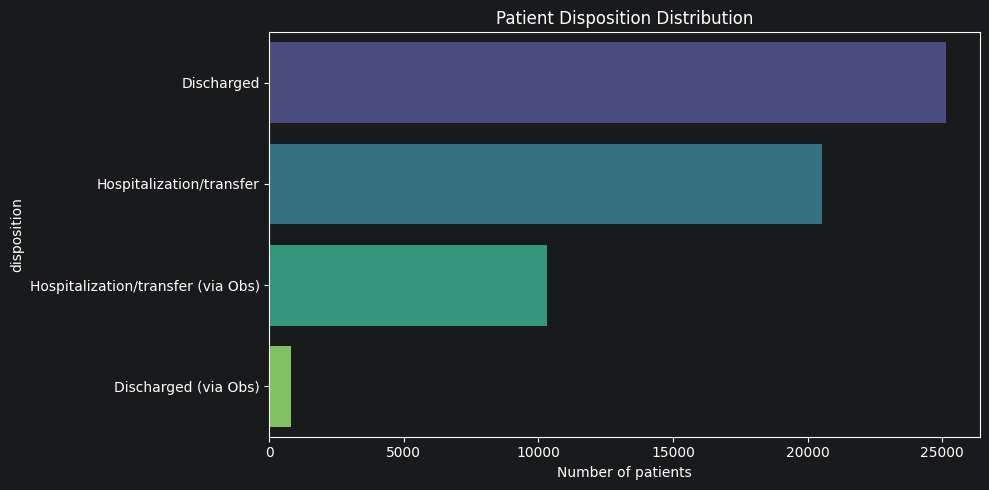

In [357]:
# ================================================================
# STEP 3 — BINARY OUTCOME ENCODING
# ================================================================
print("\n" + "=" * 60)
print("STEP 3 — BINARY OUTCOME ENCODING")
print("=" * 60)

# hospitalization: 1 = Admitted / Transferred / ICU / Obs
df_imputed['hospitalization'] = (
    df_imputed['disposition']
    .astype(str)
    .str.lower().str.strip()
    .apply(lambda v: int(any(k in str(v) for k in HOSPIT_KEYWORDS)))
)

# observation_unit: passed through UHCD/Obs
df_imputed['observation_unit'] = (
    df_imputed['disposition']
    .astype(str)
    .str.contains('Obs', case=False, na=False).astype(int)
)

# # inter_facility_transfer
# df_imputed['inter_facility_transfer'] = (
#     df_imputed['disposition']
#     .astype(str)
#     .str.contains('Transfer', case=False, na=False).astype(int)
# )

# Summary
for col in ['hospitalization', 'observation_unit',
            #'inter_facility_transfer'
            ]:
    counts = df_imputed[col].value_counts()
    pcts   = df_imputed[col].value_counts(normalize=True) * 100
    print(f"\n{col}:")
    for val in [1, 0]:
        if val in counts:
            print(f"  {val} : {counts[val]:>6} ({pcts[val]:.1f}%)")

# Mapping audit
print("\n🔍 Mapping audit (hospitalization):")
display(pd.crosstab(df_imputed['disposition'], df_imputed['hospitalization']))

# ================================================================
# STEP 4 — DISPOSITION DISTRIBUTION PLOT
# ================================================================
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_imputed, y='disposition',
    order=df_imputed['disposition'].value_counts().index,
    palette='viridis'
)
plt.title('Patient Disposition Distribution')
plt.xlabel('Number of patients')
plt.ylabel('disposition')
plt.tight_layout()
plt.savefig("disposition_distribution.png", dpi=150)
plt.show()

# =========================================================
# FORMAT AUDIT & DATA DICTIONARY CREATION
# =========================================================

In [358]:
# VISUALISATION DES FORMATS ACTUELS
# On crée un petit tableau de diagnostic
diagnostic = pd.DataFrame({
    'Type': df_imputed.dtypes,
    'Exemple': df_imputed.iloc[0], # On prend la première ligne pour voir
    'Nb_Valeurs_Uniques': df_imputed.nunique(),
    'Taux_NaN (%)': (df_imputed.isna().sum() / len(df_imputed) * 100).round(2)
})

print("### DIAGNOSTIC DES FORMATS ###")
print(diagnostic)

### DIAGNOSTIC DES FORMATS ###
                                       Type                       Exemple  \
nda                                   int64                   22030011617   
sex                                  object                             M   
age                                   int64                            39   
uam_service                           int64                          9780   
hospital                             object                           PEL   
datetime_admission                   object           2022-01-01 00:08:00   
date_sortie_urg                      object           2022-01-02 09:33:00   
date_sortie_chu                      object           2022-01-02 19:00:00   
date_sortie_urg_completee            object           2022-01-01 00:09:00   
mode_sortie_chu                      object                  A - Domicile   
decision_urgence                     object               Hospitalisation   
transport_grouped                    object  

In [359]:
# =========================================================
# DATA TYPE OPTIMIZATION (CATEGORICAL & NUMERIC)
# =========================================================

# --- 1. FEATURE ENGINEERING: AGE QUARTILES ---
if 'age' in df_imputed.columns:
    df_imputed['age_group'] = pd.cut(
        df_imputed['age'],
        bins=[14, 30, 45, 60, 75, 120],
        labels=['15-30', '31-45', '46-60', '61-75', '75+'],
        right=True
    )

# --- 2. AUTOMATED CATEGORICAL CONVERSION ---
# We identify columns based on your naming convention + explicit clinical targets
patterns = ['is_', 'has_', '_status', 'imagerie']
explicit_cats = ['transport_grouped', 'urine_dipstick_clean', 'disposition_med', 'sex', 'age_group', 'hospitalization', 'disposition']

# Dynamic selection
cols_to_categorize = [
    col for col in df_imputed.columns
    if any(p in col for p in patterns) or col in explicit_cats
]

for col in cols_to_categorize:
    df_imputed[col] = df_imputed[col].astype('category')

print(f"✅ Categorical conversion complete: {len(cols_to_categorize)} columns processed.")
print(f"   (Includes: {', '.join(cols_to_categorize[:5])}...)")

# --- 3. NUMERIC CONVERSION (NULLABLE INTEGERS) ---
# Using 'Int64' allows integers to coexist with NaNs
cols_to_int = [
    'sbp', 'dbp', 'hr', 'rr', 'gcs', 'pain',
    'age', 'triage_level'
]

for col in cols_to_int:
    if col in df_imputed.columns:
        df_imputed[col] = pd.to_numeric(df_imputed[col], errors='coerce').astype('Int64')

print("✅ Integer conversion complete for physiological vitals and age.")

# --- 4. TEXT & DATETIME STANDARDIZATION ---
# Text
for col in ['diag', 'chief_complaint']:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].astype(str).str.lower().str.strip()

# Datetimes
cols_dates = ['datetime_admission', 'sample_date', 'date_tri_ioa_begin', 'date_tri_ioa_end']
for col in cols_dates:
    if col in df_imputed.columns:
        df_imputed[col] = pd.to_datetime(df_imputed[col], errors='coerce')

print("✅ Text and Datetime formats standardized.")

✅ Categorical conversion complete: 75 columns processed.
   (Includes: sex, transport_grouped, bp_status, is_bp_measured, hr_status...)
✅ Integer conversion complete for physiological vitals and age.
✅ Text and Datetime formats standardized.


In [360]:
# =========================================================
# DATA DICTIONARY & FORMAT AUDIT
# =========================================================

# 1. Create the Audit Table
data_audit = pd.DataFrame({
    'Column Name': df_imputed.columns,
    'Data Type': [df_imputed[col].dtype for col in df_imputed.columns],
    'Category?': [pd.api.types.is_categorical_dtype(df_imputed[col]) for col in df_imputed.columns],
    'Missing Values': [df_imputed[col].isna().sum() for col in df_imputed.columns],
    'Sample Value': [df_imputed[col].dropna().iloc[0] if not df_imputed[col].dropna().empty else "Empty" for col in df_imputed.columns]
})

# 2. Add a 'Group' tag for easier reading
def tag_group(col):
    if any(p in col for p in ['is_', 'has_', '_status', 'imagerie', 'bin']): return 'Categorical/Flag'
    if any(p in col for p in ['date', 'time']): return 'Temporal'
    if col in ['age', 'sbp', 'dbp', 'hr', 'rr', 'sat', 'temp', 'gcs', 'pain']: return 'Vital Signs'
    return 'Other'

data_audit['Analysis Group'] = data_audit['Column Name'].apply(tag_group)

# 3. Display the sorted audit
print("📋 FINAL DATA FORMAT AUDIT:")
print("-" * 60)
display(data_audit.sort_values(by='Analysis Group'))

# 4. Quick Summary of Types
print("\n📊 DATA TYPE SUMMARY:")
print(df_imputed.dtypes.value_counts())

/tmp/ipykernel_3141514/1175692346.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  'Category?': [pd.api.types.is_categorical_dtype(df_imputed[col]) for col in df_imputed.columns],


📋 FINAL DATA FORMAT AUDIT:
------------------------------------------------------------


,Column Name,Data Type,Category?,Missing Values,Sample Value,Analysis Group
54,is_pain_measured,category,True,0,0,Categorical/Flag
153,is_alat,category,True,0,0,Categorical/Flag
53,pain_status,category,True,0,not_measured,Categorical/Flag
154,is_asat,category,True,0,0,Categorical/Flag
51,urine_dipstick_clean_status,category,True,0,not_measured,Categorical/Flag
50,is_urine_dipstick_clean_measured,category,True,0,0,Categorical/Flag
155,is_bnp,category,True,0,0,Categorical/Flag
48,is_pupils_measured,category,True,0,0,Categorical/Flag
47,anisocoria_status,category,True,0,not_measured,Categorical/Flag
46,pupils_status,category,True,0,not_measured,Categorical/Flag



📊 DATA TYPE SUMMARY:
object            70
category          55
float64           20
int64             13
Int64              7
datetime64[ns]     2
category           2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64


## Chief complaint exploration

In [361]:
# =========================================================
# CHIEF COMPLAINT EXPLORATION
# =========================================================

# ── Modalities list ────────────────────────────────────
all_complaints = df_imputed['chief_complaint'].value_counts()
print(f"Total modalities : {len(all_complaints)}")
print(f"\nComplete distribution :")
print(all_complaints.to_string())
top_15 = df_imputed['chief_complaint'].value_counts().head(15)

total = len(df_imputed)
total_top_15 = top_15.sum()
pct_top_15 = total_top_15 / total * 100

print(f"Total patients        : {total:,}")
print(f"Top 15 motifs         : {total_top_15:,} ({pct_top_15:.1f}%)")
print(f"Reste (Other)         : {total - total_top_15:,} ({100 - pct_top_15:.1f}%)")
print(f"\nDétail top 15 :")
for complaint, n in top_15.items():
    print(f"  {n:>5} ({n / total * 100:.1f}%)  {complaint}")
for n_top in [15, 20, 25, 30, 40, 50]:
    top = df_imputed['chief_complaint'].value_counts().head(n_top)
    pct = top.sum() / total * 100
    print(f"Top {n_top:>2} : {top.sum():>6,} patients ({pct:.1f}%)")

COMPLAINT_TRANSLATION = {
    # ── Trauma ────────────────────────────────────────────────────────────────
    'traumatisme du membre inférieur hors cuisse fracture ouverte luxation' : 'Lower limb trauma (excl. thigh, open fracture, dislocation)',
    'traumatisme du membre supérieur sans fracture ouverte sans luxation'    : 'Upper limb trauma (no open fracture, no dislocation)',
    'traumatisme crânien sans défaillance vitale'                            : 'Head trauma without vital failure',
    'plaie traumatique isolée'                                               : 'Isolated traumatic wound',
    'traumatisme de la face sans atteinte ophtalmique'                       : 'Facial trauma without ophthalmic involvement',
    'avp cinétique élevée (piéton renversé, motard, vitesse >100km/h)'       : 'High-energy MVC (pedestrian, motorcyclist, >100km/h)',
    'traumatisme sous antithrombotiques (antiagrégants ou anticoagulants)'   : 'Trauma under antithrombotic therapy',
    'traumatisme thoracique sans défaillance vitale'                         : 'Thoracic trauma without vital failure',
    'traumatisme membre supérieur avec fracture ouverte ou luxation'         : 'Upper limb trauma with open fracture or dislocation',
    'traumatisme membre inférieur (cuisse ou fracture ouverte ou luxation)'  : 'Lower limb trauma (thigh, open fracture or dislocation)',
    'traumatisme du rachis lombaire sans déficit neurologique'               : 'Lumbar spine trauma without neurological deficit',
    'traumatisme cervical sans défaillance vitale'                           : 'Cervical trauma without vital failure',
    'traumatisme du rachis dorsal sans déficit neurologique'                 : 'Thoracic spine trauma without neurological deficit',
    'traumatisme abdomen lombes bassin sans défaillance vitale'              : 'Abdominal/lumbar/pelvic trauma without vital failure',
    'traumatisme de l\'oreille'                                              : 'Ear trauma',
    'traumatisme oeil ou orbite sans défaillance vitale'                     : 'Eye or orbital trauma without vital failure',
    'traumatisme pelvien ou génital sans défaillance vitale'                 : 'Pelvic or genital trauma without vital failure',
    'chute d\'une hauteur supérieure à 4m'                                   : 'Fall from height >4m',
    'victime d\'agression physique'                                          : 'Physical assault',
    'corps étranger ou objet pénétrant dans la peau'                         : 'Foreign body or penetrating object in skin',
    'electrisation sans défaillance vitale'                                  : 'Electrical injury without vital failure',
    'inhalation de fumée sans défaillance vitale'                            : 'Smoke inhalation without vital failure',
    'victime de submersion sans défaillance vitale'                          : 'Submersion without vital failure',
    'brûlure cutanée sans défaillance vitale'                                : 'Skin burn without vital failure',

    # ── Abdominal & Digestive ─────────────────────────────────────────────────
    'douleurs abdominales récentes'                                          : 'Recent abdominal pain',
    'nausées et/ou vomissements'                                             : 'Nausea and/or vomiting',
    'diarrhées'                                                              : 'Diarrhea',
    'constipation'                                                           : 'Constipation',
    'rectorragies'                                                           : 'Rectal bleeding',
    'hématémèse'                                                             : 'Hematemesis',
    'mélaena'                                                                : 'Melena',
    'masse ou distension abdominale, ascite'                                 : 'Abdominal mass, distension or ascites',
    'problème proctologique (kyste pilonidal y compris)'                     : 'Proctological problem (incl. pilonidal cyst)',
    'corps étranger avalé sans blocage des aliments'                         : 'Swallowed foreign body without food obstruction',
    'corps étranger avalé avec blocage des aliments'                         : 'Swallowed foreign body with food obstruction',
    'dysphagie, trouble de la déglutition'                                   : 'Dysphagia or swallowing disorder',
    'rectal'                                                                 : 'Rectal complaint',

    # ── Cardiovascular ────────────────────────────────────────────────────────
    'douleur thoracique récente'                                             : 'Recent chest pain',
    'douleur thoracique non récente'                                         : 'Non-recent chest pain',
    'palpitations sans tachycardie ou douleur thoracique'                    : 'Palpitations without tachycardia or chest pain',
    'tachycardie modérée (fc entre 80 et 120/min)'                           : 'Moderate tachycardia (HR 80–120/min)',
    'tachycardie majeure (fc >180/min)'                                      : 'Severe tachycardia (HR >180/min)',
    'bradycardie majeure (fc <40/min)'                                       : 'Severe bradycardia (HR <40/min)',
    'bradycardie modérée (fc entre 40 et 60/min)'                            : 'Moderate bradycardia (HR 40–60/min)',
    'hypotension artérielle majeure (pas <80mmhg ou hypoperfusion)'          : 'Severe hypotension (SBP <80mmHg or hypoperfusion)',
    'hypotension artérielle modérée (pas <100mmhg sans hypoperfusion)'       : 'Moderate hypotension (SBP <100mmHg, no hypoperfusion)',
    'hypertension artérielle modérée (pas entre 160mmhg et 220mmhg)'         : 'Moderate hypertension (SBP 160–220mmHg)',
    'hypertension artérielle (pas >180mmhg ou pad >100mmhg)'                 : 'Hypertension (SBP >180mmHg or DBP >100mmHg)',
    'hypertension artérielle sévère (pas >220mmhg ou pad >120mmhg)'          : 'Severe hypertension (SBP >220mmHg or DBP >120mmHg)',
    'oedèmes généralisés ou oedème extensif'                                 : 'Generalized or extensive edema',
    'saignement sous antithrombotiques'                                      : 'Bleeding under antithrombotic therapy',

    # ── Neurological ─────────────────────────────────────────────────────────
    'troubles du langage récents'                                            : 'Recent speech or language disorder',
    'paralysie récente un ou plusieurs membres'                              : 'Recent limb paralysis',
    'céphalée d\'intensité sévère'                                           : 'Severe headache',
    'céphalées non récentes sans fièvre'                                     : 'Non-recent headache without fever',
    'céphalée brutale ou récente'                                            : 'Sudden or recent headache',
    'crise convulsive'                                                       : 'Seizure',
    'convulsions'                                                            : 'Convulsions',
    'malaise avec perte de conscience'                                       : 'Syncope with loss of consciousness',
    'malaise sans perte de conscience'                                       : 'Presyncope without loss of consciousness',
    'paralysie faciale récente'                                              : 'Recent facial palsy',
    'vertiges rotatoires récents'                                            : 'Recent vertigo',
    'troubles de la conscience avec glasgow entre 9 et 14'                   : 'Altered consciousness (GCS 9–14)',
    'coma avec glasgow <9'                                                   : 'Coma (GCS <9)',
    'amnésie antérograde'                                                    : 'Anterograde amnesia',
    'somnolence'                                                             : 'Somnolence',
    'tremblements'                                                           : 'Tremors',
    'mouvements involontaires anormaux'                                      : 'Abnormal involuntary movements',
    'instabilité de la marche'                                               : 'Gait instability',
    'troubles de la marche'                                                  : 'Gait disorder',
    'troubles de la sensibilité cutanée ou paresthésies'                     : 'Sensory disturbance or paresthesia',
    'trouble de la vision récent'                                            : 'Recent visual disturbance',
    'trouble de la vision non récent'                                        : 'Non-recent visual disturbance',
    'douleur radiculaire'                                                    : 'Radicular pain',

    # ── Respiratory ───────────────────────────────────────────────────────────
    'dyspnée sans détresse respiratoire aiguë (fr <30/min, pas de tirage)'   : 'Dyspnea without acute respiratory distress (RR <30, no retractions)',
    'dyspnée sans détresse respiratoire aiguë (spo2 >92% en aa)'             : 'Dyspnea without acute respiratory distress (SpO2 >92% on room air)',
    'détresse respiratoire aiguë modérée (spo2 entre 85 et 92% en aa)'       : 'Moderate acute respiratory distress (SpO2 85–92% on room air)',
    'détresse respiratoire aiguë modérée (fr entre 30 et 40, pas de tirage)' : 'Moderate acute respiratory distress (RR 30–40, no retractions)',
    'détresse respiratoire aiguë majeure (spo2 <85% en aa ou <95% au mhc)'   : 'Severe acute respiratory distress (SpO2 <85% room air or <95% on mask)',
    'détresse respiratoire aiguë majeure (fr >40/min, tirage, épuisement)'   : 'Severe acute respiratory distress (RR >40, retractions, exhaustion)',
    'détresse respiratoire aiguë majeure (dyspnée laryngée)'                 : 'Severe acute respiratory distress (laryngeal dyspnea)',
    'détresse respiratoire aiguë majeure (asthme dep<150/parole impossible)'  : 'Severe acute respiratory distress (asthma, PEF <150 or unable to speak)',
    'toux'                                                                   : 'Cough',
    'hémoptysie sans défaillance vitale'                                     : 'Hemoptysis without vital failure',
    'respiratoire (patient inconscient, pas de pouls)'                       : 'Respiratory arrest (unconscious, no pulse)',


    # ── Musculoskeletal Pain ───────────────────────────────────────────────────────
    'douleur non traumatique d\'un membre'                                   : 'Non-traumatic limb pain',
    'lombalgies'                                                             : 'Low back pain',
    'dorsalgies'                                                             : 'Mid-back pain',
    'cervicalgies'                                                           : 'Neck pain',
    'douleurs diffuses (arthralgies, myalgies)'                              : 'Diffuse pain (arthralgia, myalgia)',
    'douleur d\'une articulation sans gonflement ni fièvre'                  : 'Joint pain without swelling or fever',
    'douleur d\'une articulation avec gonflement ou fièvre'                  : 'Joint pain with swelling or fever',
    'douleurs pelviennes ou génitales récentes'                              : 'Recent pelvic or genital pain',
    'douleur faciale'                                                        : 'Facial pain',
    'patient hyperalgique (en > 7, eoc élevée)'                              : 'Hyperalgesic patient (pain >7, high opioid consumption)',

    # ── Infectious, Fever & Hypothermia────────────────────────────────────────────────────
    'fièvre'                                                                 : 'Fever',
    'fièvre (t entre 38 et 41°c) sans défaillance vitale sans neutropénie'   : 'Fever (38–41°C) without vital failure or neutropenia',
    'hyperthermie maligne (t >41°c)'                                         : 'Malignant hyperthermia (T >41°C)',
    'contact avec maladie transmissible, aes'                                : 'Contact with transmissible disease or occupational exposure',
    'maladie infectieuse'                                                    : 'Infectious disease',
    'hypothermie modérée (t entre 33 et 35°c)'                               : 'Moderate hypothermia (T 33–35°C)',
    'hypothermie profonde (t <32°c)'                                         : 'Severe hypothermia (T <32°C)',


    # ── Psychiatric & Behavioral ──────────────────────────────────────────────
    'tentative de suicide quelquesoit le mode'                               : 'Suicide attempt (any method)',
    'agitation aiguë ou hostilité'                                           : 'Acute agitation or hostility',
    'anxiété sans troubles du comportement'                                  : 'Anxiety without behavioral disorder',
    'hallucinations, délire'                                                 : 'Hallucinations or delusion',
    'trouble dépressif sans comportement suicidaire'                         : 'Depressive disorder without suicidal behavior',
    'troubles du comportement liés à l\'alcool'                              : 'Alcohol-related behavioral disorder',
    'troubles du comportement liés à une drogue'                             : 'Drug-related behavioral disorder',
    'ivresse alcoolique sans trouble du comportement'                        : 'Alcohol intoxication without behavioral disorder',
    'demande d\'aide au sevrage alcool'                                      : 'Request for alcohol withdrawal support',
    'demande d\'aide au sevrage drogue'                                      : 'Request for drug withdrawal support',
    'syndrome de sevrage alcool'                                             : 'Alcohol withdrawal syndrome',
    'syndrome de sevrage drogue'                                             : 'Drug withdrawal syndrome',
    'victime d\'agression sexuelle'                                          : 'Sexual assault victim',
    'troubles du comportement de l\'enfant'                                  : 'Behavioral disorder in child',
    'troubles du sommeil'                                                    : 'Sleep disorder',
    'anorexie mentale sans défaillance vitale'                               : 'Anorexia nervosa without vital failure',

    # ── Metabolic & Endocrine ─────────────────────────────────────────────────
    'hyperglycémie majeure (glycémie capillaire >3,50g/l ou cétonurie)'      : 'Severe hyperglycemia (BG >3.50g/L or ketonuria)',
    'hyperglycémie modérée (glycémie capillaire entre 2 et 3,50g/l)'         : 'Moderate hyperglycemia (BG 2–3.50g/L)',
    'hypoglycémie (glycémie capillaire <0,50 ou <0,70 chez le diabétique)'   : 'Hypoglycemia (BG <0.50g/L or <0.70 in diabetic)',
    'hyperkaliémie sévère (potassium >6mmol/l)'                              : 'Severe hyperkalemia (K >6mmol/L)',
    'hyperkaliémie modérée (potassium entre 4,5 et 6mmol/l)'                 : 'Moderate hyperkalemia (K 4.5–6mmol/L)',
    'hypokaliémie modérée (potassium entre 2,5 et 3,5mmol/l)'                : 'Moderate hypokalemia (K 2.5–3.5mmol/L)',
    'hypokaliémie sévère (potassium <2,5mmol/l)'                             : 'Severe hypokalemia (K <2.5mmol/L)',
    'hyponatrémie non sévère (entre 120 et 135mmol/l)'                       : 'Non-severe hyponatremia (Na 120–135mmol/L)',
    'déshydratation'                                                         : 'Dehydration',
    'ictère'                                                                 : 'Jaundice',
    'coup de chaleur/insolation'                                             : 'Heat stroke / sunstroke',

    # ── Urological, Genital & Renal ────────────────────────────────────────────────────
    'hématurie'                                                              : 'Hematuria',
    'anurie ou oligurie sans défaillance vitale'                             : 'Anuria or oliguria without vital failure',
    'insuffisance rénale aiguë non sévère (urée <30mmol/l)'                  : 'Non-severe acute kidney injury (urea <30mmol/L)',
    'insuffisance rénale aiguë sévère (urée >30mmol/l)'                      : 'Severe acute kidney injury (urea >30mmol/L)',
    'génital homme sans douleur'                                             : 'Male genital complaint without pain',
    'génital femme sans douleur'                                             : 'Female genital complaint without pain',
    'saignement génital homme'                                               : 'Male genital bleeding',
    'saignement génital femme'                                               : 'Female genital bleeding',
    'urinaire'                                                               : 'Urinary complaint',
    'anurie douloureuse / globe vésical'                                     : 'Painful anuria / bladder globe',

    # ── ENT & Ophthalmology & Dental ───────────────────────────────────────────────────
    'otalgie'                                                                : 'Ear pain',
    'epistaxis, otorragie, ou autre saignement orl'                          : 'Epistaxis, otorrhagia or other ENT bleeding',
    'troubles de l\'audition'                                                : 'Hearing disturbance',
    'douleur oculaire'                                                       : 'Eye pain',
    'obstruction nasale et rhinorrhée'                                       : 'Nasal obstruction and rhinorrhea',
    'auriculaire'                                                            : 'Auricular complaint',
    'oculaire'                                                               : 'Ocular complaint',
    'laryngite et trachéite'                                                 : 'Laryngitis and tracheitis',
    'douleur dentaire'                                                       : 'Dental pain',
    'trouble dentaire ou mandibulaire'                                       : 'Dental or mandibular disorder',

    # ── Dermatological ───────────────────────────────────────────────────────
    'eruption cutanée ou lésion cutanée superficielle sans purpura'          : 'Skin rash or superficial lesion without purpura',
    'lésion cutanée avec purpura'                                            : 'Skin lesion with purpura',
    'prurit'                                                                 : 'Pruritus',
    'cutanée'                                                                : 'Cutaneous complaint',
    'tuméfaction ou oedème localisé, face et cou'                            : 'Localized swelling or edema, face and neck',
    'tuméfaction ou oedème localisé, hors face et cou'                       : 'Localized swelling or edema, other than face and neck',
    'adénopathie(s)'                                                         : 'Lymphadenopathy',


    # ── Hematology ─────────────────────────────────────────────────
    'anémie <7g/dl sans défaillance vitale'                                  : 'Anemia <7g/dL without vital failure',
    'anémie >7g/dl sans défaillance vitale'                                  : 'Anemia >7g/dL without vital failure',
    'thrombopénie < 30 000/mm3 ou avec saignement'                           : 'Thrombocytopenia <30,000/mm³ or with bleeding',
    'thrombopénie > 30 000/mm3 sans saignement'                              : 'Thrombocytopenia >30,000/mm³ without bleeding',
    'neutropénie (pnn <500/mm3) avec ou sans fièvre'                         : 'Neutropenia (ANC <500/mm³) with or without fever',

    # ── General Deterioration ─────────────────────────────────────────────────
    'aeg (asthénie, amaigrissement, anorexie)'                               : 'General deterioration (fatigue, weight loss, anorexia)',
    '"aeg" du sujet âgé'                                                     : 'General deterioration in elderly patient',
    'chute(s) du sujet âgé ou troubles de la marche'                         : 'Fall(s) or gait disorder in elderly patient',
    'chute(s) de l\'enfant ou troubles de la marche'                         : 'Fall(s) or gait disorder in child',
    'confusion ou désorientation du sujet âgé'                               : 'Confusion or disorientation in elderly patient',
    'confusion ou désorientation (hors sujet âgé ou dément)'                 : 'Confusion or disorientation (non-elderly, non-demented)',
    'perte d\'autonomie du sujet âgé'                                        : 'Loss of autonomy in elderly patient',
    'soins palliatifs, fin de vie'                                           : 'Palliative care / end of life',

    # ── Poisoning & Intoxication ──────────────────────────────────────────────
    'intoxication accidentelle sans défaillance vitale'                      : 'Accidental poisoning without vital failure',
    'intoxication accidentelle'                                              : 'Accidental poisoning',

    # ── Administrative & Social & not classified  ───────────────────────────────────────────────
    'demande d\'examen complémentaire sans symptôme'                         : 'Request for workup without symptoms',
    'demande de certificat médical'                                          : 'Request for medical certificate',
    'demande de renouvellement d\'ordonnance'                                : 'Prescription renewal request',
    'problème social'                                                        : 'Social problem',
    'problème d\'hébergement'                                                : 'Housing problem',
    'symptôme non classé ailleurs sans critère de gravité'                   : 'Unclassified symptom without severity criterion',
    'unknown'                                                                : 'Unknown',

    # ── Medical follow up ───────────────────────────────────────────────
    'opératoire'                                                             : 'Post-operative complaint',
    'problème avec dispositif médical/sonde/stomie'                          : 'Problem with medical device, catheter or stoma',
    'problème de suture/pansement'                                           : 'Suture or dressing problem',
    'examen biologique anormal'                                              : 'Abnormal laboratory result',
    'examen radiologique anormal'                                            : 'Abnormal imaging result',
}







# ── Application ───────────────────────────────────────────────────────────────
df_imputed['chief_complaint_en'] = df_imputed['chief_complaint'].map(COMPLAINT_TRANSLATION)

# ── Vérification ──────────────────────────────────────────────────────────────
n_unmapped = df_imputed['chief_complaint_en'].isna().sum()
if n_unmapped > 0:
    print(f"⚠️  {n_unmapped} patients with untranslated chief complaint:")
    print(df_imputed[df_imputed['chief_complaint_en'].isna()]['chief_complaint'].value_counts().to_string())
else:
    print("✅ All chief complaints translated")




Total modalities : 184

Complete distribution :
chief_complaint
douleurs abdominales récentes                                             5269
traumatisme du membre inférieur hors cuisse fracture ouverte luxation     3930
traumatisme du membre supérieur sans fracture ouverte sans luxation       2310
traumatisme crânien sans défaillance vitale                               1854
troubles de la sensibilité cutanée ou paresthésies                        1618
douleur non traumatique d'un membre                                       1580
plaie traumatique isolée                                                  1527
douleur thoracique récente                                                1450
lombalgies                                                                1344
troubles du langage récents                                               1340
vertiges rotatoires récents                                               1081
malaise avec perte de conscience                                   

In [362]:
mask = df_imputed['chief_complaint'] == 'bronchiolite du nourrisson'
print(f"N = {mask.sum()}\n")
print(df_imputed[mask][['age', 'sex', 'disposition', 'triage']].to_string())

N = 1

       age sex               disposition  triage
18158   67   M  Hospitalization/transfer     3.0


In [363]:
df_imputed = df_imputed[df_imputed['chief_complaint'] != 'bronchiolite du nourrisson'].copy()
print(f"Dataset after removal: {len(df_imputed):,} patients")

Dataset after removal: 56,784 patients


In [364]:
COMPLAINT_GROUPS_EN = {

    # ── Trauma ────────────────────────────────────────────────────────────────
    'Lower limb trauma (excl. thigh, open fracture, dislocation)'            : 'Trauma',
    'Upper limb trauma (no open fracture, no dislocation)'                   : 'Trauma',
    'Head trauma without vital failure'                                      : 'Trauma',
    'Isolated traumatic wound'                                               : 'Trauma',
    'Facial trauma without ophthalmic involvement'                           : 'Trauma',
    'High-energy MVC (pedestrian, motorcyclist, >100km/h)'                   : 'Trauma',
    'Trauma under antithrombotic therapy'                                    : 'Trauma',
    'Thoracic trauma without vital failure'                                  : 'Trauma',
    'Upper limb trauma with open fracture or dislocation'                    : 'Trauma',
    'Lower limb trauma (thigh, open fracture or dislocation)'                : 'Trauma',
    'Lumbar spine trauma without neurological deficit'                       : 'Trauma',
    'Cervical trauma without vital failure'                                  : 'Trauma',
    'Thoracic spine trauma without neurological deficit'                     : 'Trauma',
    'Abdominal/lumbar/pelvic trauma without vital failure'                   : 'Trauma',
    'Ear trauma'                                                             : 'Trauma',
    'Eye or orbital trauma without vital failure'                            : 'Trauma',
    'Pelvic or genital trauma without vital failure'                         : 'Trauma',
    'Fall from height >4m'                                                   : 'Trauma',
    'Physical assault'                                                       : 'Trauma',
    'Foreign body or penetrating object in skin'                             : 'Trauma',
    'Electrical injury without vital failure'                                : 'Trauma',
    'Smoke inhalation without vital failure'                                 : 'Trauma',
    'Submersion without vital failure'                                       : 'Trauma',
    'Skin burn without vital failure'                                        : 'Trauma',

    # ── Abdominal & Digestive ─────────────────────────────────────────────────
    'Recent abdominal pain'                                                  : 'Abdominal_Digestive',
    'Nausea and/or vomiting'                                                 : 'Abdominal_Digestive',
    'Diarrhea'                                                               : 'Abdominal_Digestive',
    'Constipation'                                                           : 'Abdominal_Digestive',
    'Rectal bleeding'                                                        : 'Abdominal_Digestive',
    'Hematemesis'                                                            : 'Abdominal_Digestive',
    'Melena'                                                                 : 'Abdominal_Digestive',
    'Abdominal mass, distension or ascites'                                  : 'Abdominal_Digestive',
    'Proctological problem (incl. pilonidal cyst)'                           : 'Abdominal_Digestive',
    'Swallowed foreign body without food obstruction'                        : 'Abdominal_Digestive',
    'Swallowed foreign body with food obstruction'                           : 'Abdominal_Digestive',
    'Dysphagia or swallowing disorder'                                       : 'Abdominal_Digestive',
    'Rectal complaint'                                                       : 'Abdominal_Digestive',

    # ── Cardiovascular ────────────────────────────────────────────────────────
    'Recent chest pain'                                                      : 'Cardiovascular',
    'Non-recent chest pain'                                                  : 'Cardiovascular',
    'Palpitations without tachycardia or chest pain'                         : 'Cardiovascular',
    'Moderate tachycardia (HR 80–120/min)'                                   : 'Cardiovascular',
    'Severe tachycardia (HR >180/min)'                                       : 'Cardiovascular',
    'Severe bradycardia (HR <40/min)'                                        : 'Cardiovascular',
    'Moderate bradycardia (HR 40–60/min)'                                    : 'Cardiovascular',
    'Severe hypotension (SBP <80mmHg or hypoperfusion)'                      : 'Cardiovascular',
    'Moderate hypotension (SBP <100mmHg, no hypoperfusion)'                  : 'Cardiovascular',
    'Moderate hypertension (SBP 160–220mmHg)'                                : 'Cardiovascular',
    'Hypertension (SBP >180mmHg or DBP >100mmHg)'                            : 'Cardiovascular',
    'Severe hypertension (SBP >220mmHg or DBP >120mmHg)'                     : 'Cardiovascular',
    'Generalized or extensive edema'                                         : 'Cardiovascular',
    'Bleeding under antithrombotic therapy'                                  : 'Cardiovascular',

    # ── Neurological ─────────────────────────────────────────────────────────
    'Recent speech or language disorder'                                     : 'Neurological',
    'Recent limb paralysis'                                                  : 'Neurological',
    'Severe headache'                                                        : 'Neurological',
    'Non-recent headache without fever'                                      : 'Neurological',
    'Sudden or recent headache'                                              : 'Neurological',
    'Seizure'                                                                : 'Neurological',
    'Convulsions'                                                            : 'Neurological',
    'Syncope with loss of consciousness'                                     : 'Neurological',
    'Presyncope without loss of consciousness'                               : 'Neurological',
    'Recent facial palsy'                                                    : 'Neurological',
    'Recent vertigo'                                                         : 'Neurological',
    'Altered consciousness (GCS 9–14)'                                       : 'Neurological',
    'Coma (GCS <9)'                                                          : 'Neurological',
    'Anterograde amnesia'                                                    : 'Neurological',
    'Somnolence'                                                             : 'Neurological',
    'Tremors'                                                                : 'Neurological',
    'Abnormal involuntary movements'                                         : 'Neurological',
    'Gait instability'                                                       : 'Neurological',
    'Gait disorder'                                                          : 'Neurological',
    'Sensory disturbance or paresthesia'                                     : 'Neurological',
    'Recent visual disturbance'                                              : 'Neurological',
    'Non-recent visual disturbance'                                          : 'Neurological',
    'Radicular pain'                                                         : 'Neurological',

    # ── Respiratory ───────────────────────────────────────────────────────────
    'Dyspnea without acute respiratory distress (RR <30, no retractions)'    : 'Respiratory',
    'Dyspnea without acute respiratory distress (SpO2 >92% on room air)'     : 'Respiratory',
    'Moderate acute respiratory distress (SpO2 85–92% on room air)'          : 'Respiratory',
    'Moderate acute respiratory distress (RR 30–40, no retractions)'         : 'Respiratory',
    'Severe acute respiratory distress (SpO2 <85% room air or <95% on mask)' : 'Respiratory',
    'Severe acute respiratory distress (RR >40, retractions, exhaustion)'    : 'Respiratory',
    'Severe acute respiratory distress (laryngeal dyspnea)'                  : 'Respiratory',
    'Severe acute respiratory distress (asthma, PEF <150 or unable to speak)': 'Respiratory',
    'Cough'                                                                  : 'Respiratory',
    'Hemoptysis without vital failure'                                       : 'Respiratory',
    'Respiratory arrest (unconscious, no pulse)'                             : 'Respiratory',

    # ── Musculoskeletal ───────────────────────────────────────────────────────
    'Non-traumatic limb pain'                                                : 'Musculoskeletal',
    'Low back pain'                                                          : 'Musculoskeletal',
    'Mid-back pain'                                                          : 'Musculoskeletal',
    'Neck pain'                                                              : 'Musculoskeletal',
    'Diffuse pain (arthralgia, myalgia)'                                     : 'Musculoskeletal',
    'Joint pain without swelling or fever'                                   : 'Musculoskeletal',
    'Joint pain with swelling or fever'                                      : 'Musculoskeletal',
    'Recent pelvic or genital pain'                                          : 'Musculoskeletal',
    'Facial pain'                                                            : 'Musculoskeletal',
    'Hyperalgesic patient (pain >7, high opioid consumption)'                : 'Musculoskeletal',

    # ── Infectious, Fever & Hypothermia ──────────────────────────────────────
    'Fever'                                                                  : 'Infectious_Fever',
    'Fever (38–41°C) without vital failure or neutropenia'                   : 'Infectious_Fever',
    'Malignant hyperthermia (T >41°C)'                                       : 'Infectious_Fever',
    'Contact with transmissible disease or occupational exposure'            : 'Infectious_Fever',
    'Infectious disease'                                                     : 'Infectious_Fever',
    'Moderate hypothermia (T 33–35°C)'                                       : 'Infectious_Fever',
    'Severe hypothermia (T <32°C)'                                           : 'Infectious_Fever',

    # ── Psychiatric & Behavioral ──────────────────────────────────────────────
    'Suicide attempt (any method)'                                           : 'Psychiatric_Behavioral',
    'Acute agitation or hostility'                                           : 'Psychiatric_Behavioral',
    'Anxiety without behavioral disorder'                                    : 'Psychiatric_Behavioral',
    'Hallucinations or delusion'                                             : 'Psychiatric_Behavioral',
    'Depressive disorder without suicidal behavior'                          : 'Psychiatric_Behavioral',
    'Alcohol-related behavioral disorder'                                    : 'Psychiatric_Behavioral',
    'Drug-related behavioral disorder'                                       : 'Psychiatric_Behavioral',
    'Alcohol intoxication without behavioral disorder'                       : 'Psychiatric_Behavioral',
    'Request for alcohol withdrawal support'                                 : 'Psychiatric_Behavioral',
    'Request for drug withdrawal support'                                    : 'Psychiatric_Behavioral',
    'Alcohol withdrawal syndrome'                                            : 'Psychiatric_Behavioral',
    'Drug withdrawal syndrome'                                               : 'Psychiatric_Behavioral',
    'Sexual assault victim'                                                  : 'Psychiatric_Behavioral',
    'Behavioral disorder in child'                                           : 'Psychiatric_Behavioral',
    'Sleep disorder'                                                         : 'Psychiatric_Behavioral',
    'Anorexia nervosa without vital failure'                                 : 'Psychiatric_Behavioral',

    # ── Metabolic & Endocrine ─────────────────────────────────────────────────
    'Severe hyperglycemia (BG >3.50g/L or ketonuria)'                        : 'Metabolic_Endocrine',
    'Moderate hyperglycemia (BG 2–3.50g/L)'                                  : 'Metabolic_Endocrine',
    'Hypoglycemia (BG <0.50g/L or <0.70 in diabetic)'                        : 'Metabolic_Endocrine',
    'Severe hyperkalemia (K >6mmol/L)'                                       : 'Metabolic_Endocrine',
    'Moderate hyperkalemia (K 4.5–6mmol/L)'                                  : 'Metabolic_Endocrine',
    'Moderate hypokalemia (K 2.5–3.5mmol/L)'                                 : 'Metabolic_Endocrine',
    'Severe hypokalemia (K <2.5mmol/L)'                                      : 'Metabolic_Endocrine',
    'Non-severe hyponatremia (Na 120–135mmol/L)'                             : 'Metabolic_Endocrine',
    'Dehydration'                                                            : 'Metabolic_Endocrine',
    'Jaundice'                                                               : 'Metabolic_Endocrine',
    'Heat stroke / sunstroke'                                                : 'Metabolic_Endocrine',

    # ── Urological, Genital & Renal ───────────────────────────────────────────
    'Hematuria'                                                              : 'Urogenital_Renal',
    'Anuria or oliguria without vital failure'                               : 'Urogenital_Renal',
    'Painful anuria / bladder globe'                                         : 'Urogenital_Renal',
    'Non-severe acute kidney injury (urea <30mmol/L)'                        : 'Urogenital_Renal',
    'Severe acute kidney injury (urea >30mmol/L)'                            : 'Urogenital_Renal',
    'Male genital complaint without pain'                                    : 'Urogenital_Renal',
    'Female genital complaint without pain'                                  : 'Urogenital_Renal',
    'Male genital bleeding'                                                  : 'Urogenital_Renal',
    'Female genital bleeding'                                                : 'Urogenital_Renal',
    'Urinary complaint'                                                      : 'Urogenital_Renal',

    # ── ENT, Ophthalmology & Dental ───────────────────────────────────────────
    'Ear pain'                                                               : 'ENT_Ophthalmology_Dental',
    'Epistaxis, otorrhagia or other ENT bleeding'                            : 'ENT_Ophthalmology_Dental',
    'Hearing disturbance'                                                    : 'ENT_Ophthalmology_Dental',
    'Eye pain'                                                               : 'ENT_Ophthalmology_Dental',
    'Nasal obstruction and rhinorrhea'                                       : 'ENT_Ophthalmology_Dental',
    'Auricular complaint'                                                    : 'ENT_Ophthalmology_Dental',
    'Ocular complaint'                                                       : 'ENT_Ophthalmology_Dental',
    'Laryngitis and tracheitis'                                              : 'ENT_Ophthalmology_Dental',
    'Dental pain'                                                            : 'ENT_Ophthalmology_Dental',
    'Dental or mandibular disorder'                                          : 'ENT_Ophthalmology_Dental',

    # ── Dermatological ───────────────────────────────────────────────────────
    'Skin rash or superficial lesion without purpura'                        : 'Dermatological',
    'Skin lesion with purpura'                                               : 'Dermatological',
    'Pruritus'                                                               : 'Dermatological',
    'Cutaneous complaint'                                                    : 'Dermatological',
    'Localized swelling or edema, face and neck'                             : 'Dermatological',
    'Localized swelling or edema, other than face and neck'                  : 'Dermatological',
    'Lymphadenopathy'                                                        : 'Dermatological',

    # ── Hematology ────────────────────────────────────────────────────────────
    'Anemia <7g/dL without vital failure'                                    : 'Hematology',
    'Anemia >7g/dL without vital failure'                                    : 'Hematology',
    'Thrombocytopenia <30,000/mm³ or with bleeding'                          : 'Hematology',
    'Thrombocytopenia >30,000/mm³ without bleeding'                          : 'Hematology',
    'Neutropenia (ANC <500/mm³) with or without fever'                       : 'Hematology',

    # ── General Deterioration ─────────────────────────────────────────────────
    'General deterioration (fatigue, weight loss, anorexia)'                 : 'General_Deterioration',
    'General deterioration in elderly patient'                               : 'General_Deterioration',
    'Fall(s) or gait disorder in elderly patient'                            : 'General_Deterioration',
    'Fall(s) or gait disorder in child'                                      : 'General_Deterioration',
    'Confusion or disorientation in elderly patient'                         : 'General_Deterioration',
    'Confusion or disorientation (non-elderly, non-demented)'                : 'General_Deterioration',
    'Loss of autonomy in elderly patient'                                    : 'General_Deterioration',
    'Palliative care / end of life'                                          : 'General_Deterioration',

    # ── Poisoning & Intoxication ──────────────────────────────────────────────
    'Accidental poisoning without vital failure'                             : 'Poisoning_Intoxication',
    'Accidental poisoning'                                                   : 'Poisoning_Intoxication',

    # ── Medical Followup ─────────────────────────────────────────────────────
    'Request for workup without symptoms'                                    : 'Medical_Followup',
    'Post-operative complaint'                                               : 'Medical_Followup',
    'Problem with medical device, catheter or stoma'                         : 'Medical_Followup',
    'Suture or dressing problem'                                             : 'Medical_Followup',
    'Abnormal laboratory result'                                             : 'Medical_Followup',
    'Abnormal imaging result'                                                : 'Medical_Followup',

    # ── Administrative, Social & Unclassified───────────────────────────────────────────────
    'Request for medical certificate'                                        : 'Administrative_Social_Unclassified',
    'Prescription renewal request'                                           : 'Administrative_Social_Unclassified',
    'Social problem'                                                         : 'Administrative_Social_Unclassified',
    'Housing problem'                                                        : 'Administrative_Social_Unclassified',
    'Unclassified symptom without severity criterion'                        : 'Administrative_Social_Unclassified',
    'Unknown'                                                                : 'Administrative_Social_Unclassified',


}

# ── Application ───────────────────────────────────────────────────────────────
df_imputed['complaint_category'] = df_imputed['chief_complaint_en'].map(COMPLAINT_GROUPS_EN).fillna('Other')

# ── Vérification ──────────────────────────────────────────────────────────────
n_unmapped = (df_imputed['complaint_category'] == 'Other').sum()
if n_unmapped > 0:
    print(f"⚠️  {n_unmapped} patients with unmapped category:")
    print(df_imputed[df_imputed['complaint_category'] == 'Other']['chief_complaint_en'].value_counts().to_string())
else:
    print("✅ All chief complaints categorized")

# ── Distribution ──────────────────────────────────────────────────────────────
dist  = df_imputed['complaint_category'].value_counts()
total = len(df_imputed)
print(f"\nDistribution of complaint categories ({len(dist)} categories):")
for cat, n in dist.items():
    print(f"  {n:>6,} ({n/total*100:.1f}%)  {cat}")

✅ All chief complaints categorized

Distribution of complaint categories (17 categories):
  13,961 (24.6%)  Trauma
  12,399 (21.8%)  Neurological
   7,232 (12.7%)  Abdominal_Digestive
   5,582 (9.8%)  Musculoskeletal
   2,827 (5.0%)  Cardiovascular
   2,444 (4.3%)  Respiratory
   2,380 (4.2%)  General_Deterioration
   1,898 (3.3%)  Dermatological
   1,817 (3.2%)  ENT_Ophthalmology_Dental
   1,723 (3.0%)  Medical_Followup
   1,318 (2.3%)  Psychiatric_Behavioral
   1,005 (1.8%)  Infectious_Fever
     904 (1.6%)  Urogenital_Renal
     557 (1.0%)  Administrative_Social_Unclassified
     302 (0.5%)  Metabolic_Endocrine
     229 (0.4%)  Hematology
     206 (0.4%)  Poisoning_Intoxication


In [365]:
print(f"Unclassified : {(df_imputed['complaint_category'] == 'Unclassified').sum():,} ({(df_imputed['complaint_category'] == 'Unclassified').mean()*100:.1f}%)")
print(f"NaN          : {df_imputed['complaint_category'].isna().sum():,} ({df_imputed['complaint_category'].isna().mean()*100:.1f}%)")

print("Triage distribution — Unclassified :")
print(df_imputed[df_imputed['complaint_category'] == 'Unclassified']['triage'].value_counts().sort_index())

Unclassified : 0 (0.0%)
NaN          : 0 (0.0%)
Triage distribution — Unclassified :
Series([], Name: count, dtype: int64)


In [366]:
# sauvegarde du df_imputed nettoyé et prêt pour l'analyse
df_imputed.to_csv("Datasets/df_final_binaire_imputed.csv", index=False)
print("\n✅ Le gros fichier 'df_final_binaire_imputed.csv' est prêt")


✅ Le gros fichier 'df_final_binaire_imputed.csv' est prêt
